# Implementación LightGBM

In [13]:
# Librerías a utilizar
# usar %pip si falta alguna por instalar

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import holidays
import gc
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score
import joblib
from IPython.display import display, HTML
import warnings
from functools import reduce
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from matplotlib.backends.backend_pdf import PdfPages
import os
import optuna
from optuna.integration import LightGBMPruningCallback
from IPython.display import clear_output

In [14]:
# IMPORTANTE
# Días a predecir: ajustar según necesidad, esta variable se utiliza tanto para la 
# generación del dataset de entrenamiento como para la predicción final.
# Por lo general funciona mejor con un horizonte múltiple de 7 días (1 semana), pero se puede ajustar según el caso.
dias_pred = 28

## Carga de datos finales

### Función para crear features

In [15]:
def generar_dataset(df_raw, df_antiguedad_ref, dias_prediccion=dias_pred, cybers_list=None):
    """
    Toma el DataFrame después de la limpieza y devuelve el DataFrame final listo para entrenar el modelo.
    Parámetros:
    - df_raw: DataFrame original con variables limpias.
    - df_antiguedad_ref: DataFrame con fechas de primera transacción por comercio.
    - dias_prediccion: Número de días para las variables futuras.
    - cybers_list: Lista de fechas de Cyber Events.
    Retorna:
    - df_final: DataFrame listo para modelar con todas las features generadas.
    """

    # Copiamos para no modificar el original
    df = df_raw.copy()

    # Asegurar formato fecha en datetime
    df['fecha_trx'] = pd.to_datetime(df['fecha_trx'])


    # Procesamiento de Identidad

    # Asegurar que nombre_comercio es string
    df['nombre_comercio'] = df['nombre_comercio'].astype(str).str.upper().str.strip()
    # Label Encoding de nombres de comercio
    encoder = LabelEncoder()
    df['id_comercio_num'] = encoder.fit_transform(df['nombre_comercio'])
    # MCC a entero (rellenar nulos con 0, aunque idealmente no debería haber nulos)
    df['mcc'] = df['mcc'].fillna(0).astype(int)
    
    
    # Procesamiento de antigüedad

    # Cruzar con tabla de fechas de primera transacción (verificar tablas de abajo)
    df_ref = df_antiguedad_ref[['nombre_fantasia', 'fecha_primera_tx']].copy()
    df_ref.columns = ['nombre_comercio', 'fecha_primera_tx']
    # Convertir a datetime (dayfirst=True para formato CL día-mes-año)
    df_ref['fecha_primera_tx'] = pd.to_datetime(df_ref['fecha_primera_tx'], dayfirst=True)
    # Cruzar para definir fecha_primera_tx
    df = df.merge(df_ref, on='nombre_comercio', how='left')
    # Cálculo de la diferencia en días (en float para poder dividir)
    dias_float = (df['fecha_trx'] - df['fecha_primera_tx']) / np.timedelta64(1, 'D')
    # Conversión a meses truncados (dividir por promedio de días en un mes, es una aproximación aceptable)
    df['antiguedad_meses'] = (dias_float / 30.44).fillna(-1).astype(int)
    # Limpieza
    df.drop(columns=['fecha_primera_tx', 'nombre_comercio'], errors='ignore', inplace=True)
    del df_ref
    gc.collect() # Liberar memoria


    # Procesamiento de eventos

    # Determinar rango de fechas para calendario (un poco de margen hacia el futuro por si acaso)
    fecha_min = df['fecha_trx'].min()
    fecha_max = df['fecha_trx'].max() + pd.Timedelta(days=dias_prediccion + 10)
    
    # Obtener Feriados Chile dinámicamente
    año_min, año_max = fecha_min.year, fecha_max.year
    cl_holidays = holidays.CL(years=range(año_min, año_max + 1))
    # Convertir a datetime
    feriados_dt = pd.to_datetime(sorted(list(cl_holidays.keys())))
    cybers_dt = pd.to_datetime(cybers_list)


    # Procesamiento de variables temporales

    # Crear calendario para variables temporales
    df_cal = pd.DataFrame({'fecha': pd.date_range(start=fecha_min, end=fecha_max, freq='D')})
    

    # Procesamiento de eventos futuros
    
    # Series binarias de eventos (1 si es evento, 0 si no)
    df_cal['es_feriado'] = df_cal['fecha'].isin(feriados_dt).astype(int)
    df_cal['es_cyber'] = df_cal['fecha'].isin(cybers_dt).astype(int)
    
    # Cálculo de variables futuras usando rolling forward (shift -1 para empezar desde "mañana")
    indexer = pd.api.indexers.FixedForwardWindowIndexer(window_size=dias_prediccion)
    df_cal['q_feriados_futuros'] = df_cal['es_feriado'].shift(-1).rolling(window=indexer).sum().fillna(0)
    df_cal['flag_cyber_futuro'] = df_cal['es_cyber'].shift(-1).rolling(window=indexer).max().fillna(0)
    
    # Seleccionar columnas útiles y Pegar
    cols_cal = ['fecha', 'q_feriados_futuros', 'flag_cyber_futuro']
    df = df.merge(df_cal[cols_cal], left_on='fecha_trx', right_on='fecha', how='left')
    df.drop(columns=['fecha'], inplace=True)
    
    # Limpieza
    del df_cal, feriados_dt, cybers_dt
    gc.collect()


    # Agregación diaria y generación de features

    # Normalización de Texto (para evitar problemas de mayúsculas/acentos/espacios, aunque no debería haber)
    cat_prod = df['categoria_producto'].astype(str).str.upper().str.strip()
    cat_prod = cat_prod.str.replace('É','E').str.replace('Á','A').str.replace('Í','I')
    marca = df['marca_liq'].astype(str).str.upper().str.strip()
    presencia = df['tarjeta_presente'].astype(str).str.upper().str.strip()

    # Variables
    df['is_debito'] = np.where(cat_prod.str.contains('DEBITO'), df['tpv'], 0)
    df['is_credito'] = np.where(cat_prod.str.contains('CREDITO'), df['tpv'], 0)
    df['is_visa'] = np.where(marca.str.contains('VISA'), df['tpv'], 0)
    df['is_master'] = np.where(marca.str.contains('MASTERCARD'), df['tpv'], 0)
    # df['is_amex'] = np.where(marca.str.contains('AMEX'), df['tpv'], 0) # Si se quisiera agregar Amex como categoría aparte
    df['is_inter'] = np.where(df['nacionalidad'] == 'Internacional', df['tpv'], 0)
    df['is_presente'] = np.where(presencia == 'SI', df['tpv'], 0)


    # Borramos variables de texto ya que no se usarán más
    df.drop(columns=['categoria_producto', 'marca_liq', 'nacionalidad'], inplace=True)

    # Reglas de agregación diarias por id_comercio_num + mcc + fecha_trx
    reglas = {
        'tpv': 'sum', 'cantidad_tx': 'sum',
        'is_debito': 'sum', 'is_credito': 'sum', 
        'is_visa': 'sum', 'is_master': 'sum', 'is_inter': 'sum', 'is_presente': 'sum',
        'antiguedad_meses': 'max', 
        'q_feriados_futuros': 'first', 'flag_cyber_futuro': 'first'
    }
    df_day = df.groupby(['id_comercio_num', 'mcc', 'fecha_trx']).agg(reglas).reset_index()

    # Eliminar df original para liberar memoria
    del df, cat_prod, marca, presencia
    gc.collect()

    # Rellenar huecos en el esquema completo

    # Crear esqueleto completo de combinaciones posibles
    pares = df_day[['id_comercio_num', 'mcc']].drop_duplicates()
    # Rango completo de fechas
    rango_fechas = pd.DataFrame({'fecha_trx': pd.date_range(fecha_min, df_day['fecha_trx'].max(), freq='D')})
    
    pares['key'] = 1; rango_fechas['key'] = 1
    skeleton = pd.merge(pares, rango_fechas, on='key').drop('key', axis=1)
    # DataFrame con estructura completa
    df_full = pd.merge(skeleton, df_day, on=['id_comercio_num', 'mcc', 'fecha_trx'], how='left')

    # Limpieza para liberar memoria
    del pares, rango_fechas, skeleton, df_day
    gc.collect()

    # Rellenar Nulos
    cols_vol = ['tpv', 'cantidad_tx', 'is_debito', 'is_credito', 'is_visa', 'is_master', 'is_inter', 'is_presente']
    df_full[cols_vol] = df_full[cols_vol].fillna(0)

    # Downcast de tipos para ahorrar memoria en caso de ser necesario
    # for c in cols_vol:
    #     df_full[c] = df_full[c].astype(np.float32)

    mes = df_full['fecha_trx'].dt.month
    dia_sem = df_full['fecha_trx'].dt.dayofweek
    dia_mes = df_full['fecha_trx'].dt.day
    dias_en_mes = df_full['fecha_trx'].dt.days_in_month

    # Variable de días restantes del mes en curso
    df_full['dias_rest_mes_actual'] = (dias_en_mes - dia_mes).astype(int)
    
    # Ciclos (Seno/Coseno)
    df_full['mes_sin'] = np.sin(2 * np.pi * mes / 12)
    df_full['mes_cos'] = np.cos(2 * np.pi * mes / 12)
    df_full['dia_semana_sin'] = np.sin(2 * np.pi * dia_sem / 7)
    df_full['dia_semana_cos'] = np.cos(2 * np.pi * dia_sem / 7)
    df_full['dia_mes_sin'] = np.sin(2 * np.pi * dia_mes / dias_en_mes)
    df_full['dia_mes_cos'] = np.cos(2 * np.pi * dia_mes / dias_en_mes)
    
    # Rellenar antigüedad por ID (ignorando MCC)
    df_full['antiguedad_meses'] = df_full.groupby('id_comercio_num')['antiguedad_meses'].transform(lambda x: x.ffill().bfill()).fillna(-1).astype(int)
    df_full['antiguedad_meses'] = df_full.groupby(['id_comercio_num', 'fecha_trx'])['antiguedad_meses'].transform('max')
    
    # Rellenar temporales por fecha
    cols_temp = ['dias_rest_mes_actual', 'mes_sin', 'mes_cos', 'dia_semana_sin', 
                 'q_feriados_futuros', 'flag_cyber_futuro']
    for col in cols_temp:
        df_full[col] = df_full.groupby('fecha_trx')[col].transform('first').fillna(0)


    # Procesamiento de variables agregadas con rolling windows

    # Ordenar DataFrame
    df_full = df_full.sort_values(['id_comercio_num', 'mcc', 'fecha_trx']).reset_index(drop=True)
    g = df_full.groupby(['id_comercio_num', 'mcc'])
    
    # Asignaciones con .values para evitar errores de índice
    tpv = g['tpv']; tx = g['cantidad_tx']
    
    # Agregar .float32 si es necesario para ahorrar memoria en las siguientes líneas

    # TPV Rolling
    df_full['tpv_acumulado_7d'] = tpv.rolling(7).sum().values
    df_full['tpv_acumulado_15d'] = tpv.rolling(15).sum().values
    df_full['tpv_acumulado_30d'] = tpv.rolling(30).sum().values
    df_full['tpv_acumulado_Xd'] = tpv.rolling(dias_prediccion).sum().values
    # Medias TPV y Transacciones
    df_full['media_movil_7d'] = tpv.rolling(7).mean().values
    df_full['media_movil_30d'] = tpv.rolling(30).mean().values
    df_full['media_tx_7d'] = tx.rolling(7).mean().values
    df_full['media_tx_30d'] = tx.rolling(30).mean().values
    # Volatilidad y Aceleración
    df_full['volatilidad_tpv_30d'] = tpv.rolling(30).std().values
    df_full['aceleracion_tpv'] = df_full['media_movil_7d'] / (df_full['media_movil_30d'] + 1)
    df_full['aceleracion_tx'] = df_full['media_tx_7d'] / (df_full['media_tx_30d'] + 1)
    # Cantidad Rolling
    df_full['cantidad_tx_7d'] = tx.rolling(7).sum().values
    df_full['cantidad_tx_30d'] = tx.rolling(30).sum().values
    # Ticket Promedio
    df_full['ticket_promedio_7d'] = (df_full['tpv_acumulado_7d'] / df_full['cantidad_tx_7d'].replace(0, np.nan)).fillna(0)
    df_full['ticket_promedio_30d'] = (df_full['tpv_acumulado_30d'] / df_full['cantidad_tx_30d'].replace(0, np.nan)).fillna(0)

    # Mix
    total_30 = df_full['tpv_acumulado_30d'].replace(0, np.nan)

    # Función helper para calcular pct y borrar col
    def calc_pct_and_drop(col_name):
        res = (g[col_name].rolling(30).sum().values / total_30).astype(np.float32)
        df_full.drop(columns=[col_name], inplace=True) # Borramos la auxiliar 'is_...' aquí mismo
        return res
    
    df_full['pct_debito_30d'] = calc_pct_and_drop('is_debito')
    df_full['pct_credito_30d'] = calc_pct_and_drop('is_credito')
    df_full['pct_visa_30d'] = calc_pct_and_drop('is_visa')
    df_full['pct_mastercard_30d'] = calc_pct_and_drop('is_master')
    df_full['pct_internacional_30d'] = calc_pct_and_drop('is_inter')
    df_full['pct_presente_30d'] = calc_pct_and_drop('is_presente')
    
    # Target
    indexer_fwd = pd.api.indexers.FixedForwardWindowIndexer(window_size=dias_prediccion)
    df_full['tpv_futuro'] = g['tpv'].shift(-1).rolling(window=indexer_fwd).sum().values
    df_full['tpv_futuro_año_anterior'] = g['tpv_futuro'].shift(365).values

    # Limpieza Final
    # Solo nos quedamos con las filas válidas
    df_final = df_full.dropna(subset=['tpv_futuro'])
    
    del df_full, g, tpv, tx
    gc.collect()
    

    return df_final, encoder

### Import o creación de df final

In [28]:
def generar_dataset_entrenamiento(dias_pred=dias_pred, sobreescribir=True):
    """
    Genera o carga el dataset de entrenamiento en base a la función generar_dataset.
    
    Args:
        dias_pred (int): Número de días para la predicción.
        sobreescribir (bool): Si es True, regenera los archivos aunque existan.
    """
    
    # Definimos las rutas
    RUTA_CARPETA_DATA = Path('../data')
    ARCHIVO_INPUT = RUTA_CARPETA_DATA / 'dataset_inicial_limpio.parquet'
    ARCHIVO_OUTPUT = RUTA_CARPETA_DATA / f'dataset_entrenamiento_{dias_pred}dias.parquet'
    ARCHIVO_ENCODER = RUTA_CARPETA_DATA / 'encoder_comercios.joblib'

    # Si archivos existen y no se quiere sobreescribir, los cargamos
    if ARCHIVO_OUTPUT.exists() and ARCHIVO_ENCODER.exists() and not sobreescribir:
        print(f"Archivos encontrados.")
        
        print(f"Cargando dataset desde: {ARCHIVO_OUTPUT}")
        df_final = pd.read_parquet(ARCHIVO_OUTPUT, engine='fastparquet')
        
        print(f"Cargando encoder desde: {ARCHIVO_ENCODER}")
        encoder = joblib.load(ARCHIVO_ENCODER)
        
        return df_final, encoder

    # Si no existen o se quiere sobreescribir, generamos el dataset
    else:
        if sobreescribir:
            print(f"Modo sobreescribir activado. Se regenerarán los archivos.")
        else:
            print(f"No se encontró {ARCHIVO_OUTPUT}")
        
        if ARCHIVO_INPUT.exists():
            print("Archivo inicial encontrado. Cargando datos crudos...")
            
            # Cargar datos limpios previos
            df_raw = pd.read_parquet(ARCHIVO_INPUT, engine='fastparquet')
            
            # Comercios a mantener (editar según necesidad)
            comercios_a_mantener = [
                'FLOW S.A.', 'PAYU', 'CABIFY', 'SUMUP CHILE PAYMENTS S.A', 
                'CLPRO SPA', 'PAYSCAN SPA', 'RECIBOPAGOS SPA', 'MERCPAGO', 
                'PEDIDOS YA', 'PAGSEGURO', 'FUDO', 'HAULMER SPA', 'DLOCAL', 
                'RAPPI', 'EBANX CHILE S.A.', 'EBANX', 'DELIVERY HERO STORES CHILE SPA', 
                'NUVEI CHILE SPA', 'TOKU SPA', 'ITAU CORPBANCA', 'PAGSMILE', 
                'INDRIVE', 'PAYKU SPA', 'PPRO', 'VIRTUALPOS' 
            ]
            
            # Filtramos incluyendo solo los que están en la lista (.isin)
            df_raw = df_raw[df_raw['nombre_comercio'].isin(comercios_a_mantener)].copy()
            

            # Definir listas de eventos, actualizar según necesidad
            mis_cybers = [
                '2022-05-30', '2022-05-31', '2022-06-01',
                '2022-10-03', '2022-10-04', '2022-10-05', '2022-11-25',
                '2023-05-29', '2023-05-30', '2023-05-31',
                '2023-10-02', '2023-10-03', '2023-10-04', '2023-11-24',
                '2024-06-03', '2024-06-04', '2024-06-05',
                '2024-09-30', '2024-10-01', '2024-10-02', '2024-11-29',
                '2025-06-02', '2025-06-03', '2025-06-04',
                '2025-10-06', '2025-10-07', '2025-10-08', '2025-11-28',
                '2026-06-02', '2026-06-03', '2026-06-04',
                '2026-09-30', '2026-10-01', '2026-10-02', '2026-11-28'
            ]
            
            # Tabla de antigüedad, actualizar según necesidad (estos se encontraron a mano directamente en la base)
            data_antiguedad_dict = {
                'nombre_fantasia': [
                    'FLOW S.A.', 'PAYU', 'CABIFY', 'SUMUP CHILE PAYMENTS S.A', 
                    'CLPRO SPA', 'PAYSCAN SPA', 'RECIBOPAGOS SPA', 'MERCPAGO', 
                    'PEDIDOS YA', 'PAGSEGURO', 'FUDO', 'HAULMER SPA', 'DLOCAL', 
                    'RAPPI', 'EBANX CHILE S.A.', 'EBANX', 'DELIVERY HERO STORES CHILE SPA', 
                    'NUVEI CHILE SPA', 'TOKU SPA', 'ITAU CORPBANCA', 'PAGSMILE', 
                    'INDRIVE', 'PAYKU SPA', 'PPRO', 'VIRTUALPOS'
                ],
                'fecha_primera_tx': [
                    '28-03-2025', '08-03-2022', '18-09-2021', '05-10-2022', 
                    '31-01-2023', '01-11-2024', '03-10-2025', '11-11-2021', 
                    '30-09-2021', '07-12-2023', '19-12-2023', '14-03-2025', 
                    '24-04-2021', '19-03-2021', '23-07-2021', '17-03-2022', 
                    '17-08-2022', '08-10-2020', '19-12-2022', '13-03-2023', 
                    '02-08-2023', '23-10-2023', '08-05-2024', '14-02-2025', '02-10-2025'
                ]
            }
            df_tabla_antiguedad = pd.DataFrame(data_antiguedad_dict)

            # Ejecutar generación de features
            df_final, encoder = generar_dataset(
                df_raw=df_raw, 
                df_antiguedad_ref=df_tabla_antiguedad, 
                dias_prediccion=dias_pred, 
                cybers_list=mis_cybers
            )
            
            # Guardar resultado final (DataFrame)
            print(f"Guardando dataset en: {ARCHIVO_OUTPUT}")
            RUTA_CARPETA_DATA.mkdir(parents=True, exist_ok=True)
            df_final.to_parquet(ARCHIVO_OUTPUT, index=False, compression='snappy', engine='fastparquet')

            # Guardamos el "diccionario" de nombres para usarlo después
            print(f"Guardando encoder de nombres en: {ARCHIVO_ENCODER}")
            joblib.dump(encoder, ARCHIVO_ENCODER)

            print("Proceso completado exitosamente.") 
            print("Dimensiones del dataset final: ", df_final.shape)
            
            return df_final, encoder
            
        else:
            print(f"ERROR CRÍTICO: No existe el archivo de entrada '{ARCHIVO_INPUT}'.")
            print("Por favor ejecuta primero el script de limpieza inicial para generar ese archivo.")
            print("La sección Guardado del dataset inicial limpio de Análisis y limpieza de datos iniciales.")
            return None, None


# Adecuar cantidad de días de predicción y si se quiere sobreescribir o no

# Opción 1: Cargar si existe, crear si no existe (comportamiento original)
# df_final, encoder = generar_dataset_entrenamiento(dias_pred=30, sobreescribir=False)

# Opción 2: Forzar la regeneración del archivo aunque ya exista
df_final, encoder = generar_dataset_entrenamiento(dias_pred=28, sobreescribir=True)

Modo sobreescribir activado. Se regenerarán los archivos.
Archivo inicial encontrado. Cargando datos crudos...
Guardando dataset en: ..\data\dataset_entrenamiento_28dias.parquet
Guardando encoder de nombres en: ..\data\encoder_comercios.joblib
Proceso completado exitosamente.
Dimensiones del dataset final:  (875472, 38)


In [29]:
# Mostrar las primeras filas transpuestas para ver todas las variabls en horizontal
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
display(df_final.sample(5).T)

,197055,725409,342838,400851,6172
id_comercio_num,7,14,7,10,3
mcc,5199,8999,8021,4784,4121
fecha_trx,2022-04-22 00:00:00,2022-10-25 00:00:00,2025-03-16 00:00:00,2024-09-22 00:00:00,2022-07-24 00:00:00
tpv,0.0,0.0,0.0,159100.0,46272322.0
cantidad_tx,0.0,0.0,0.0,10.0,11856.0
antiguedad_meses,10,46,10,50,57
q_feriados_futuros,1.0,2.0,0.0,1.0,1.0
flag_cyber_futuro,0.0,0.0,0.0,1.0,0.0
dias_rest_mes_actual,8,6,15,8,7
mes_sin,0.866025,-0.866025,1.0,-1.0,-0.5


## Análisis exploratorio de datos (EDA)

PENDIENTE: Agregar más pasos en el análisis exploratorio que solo un mapa de correlaciones. 

In [30]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 875472 entries, 0 to 892187
Data columns (total 38 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   id_comercio_num          875472 non-null  int64         
 1   mcc                      875472 non-null  int64         
 2   fecha_trx                875472 non-null  datetime64[ns]
 3   tpv                      875472 non-null  float64       
 4   cantidad_tx              875472 non-null  float64       
 5   antiguedad_meses         875472 non-null  int64         
 6   q_feriados_futuros       875472 non-null  float64       
 7   flag_cyber_futuro        875472 non-null  float64       
 8   dias_rest_mes_actual     875472 non-null  int64         
 9   mes_sin                  875472 non-null  float64       
 10  mes_cos                  875472 non-null  float64       
 11  dia_semana_sin           875472 non-null  float64       
 12  dia_semana_cos       

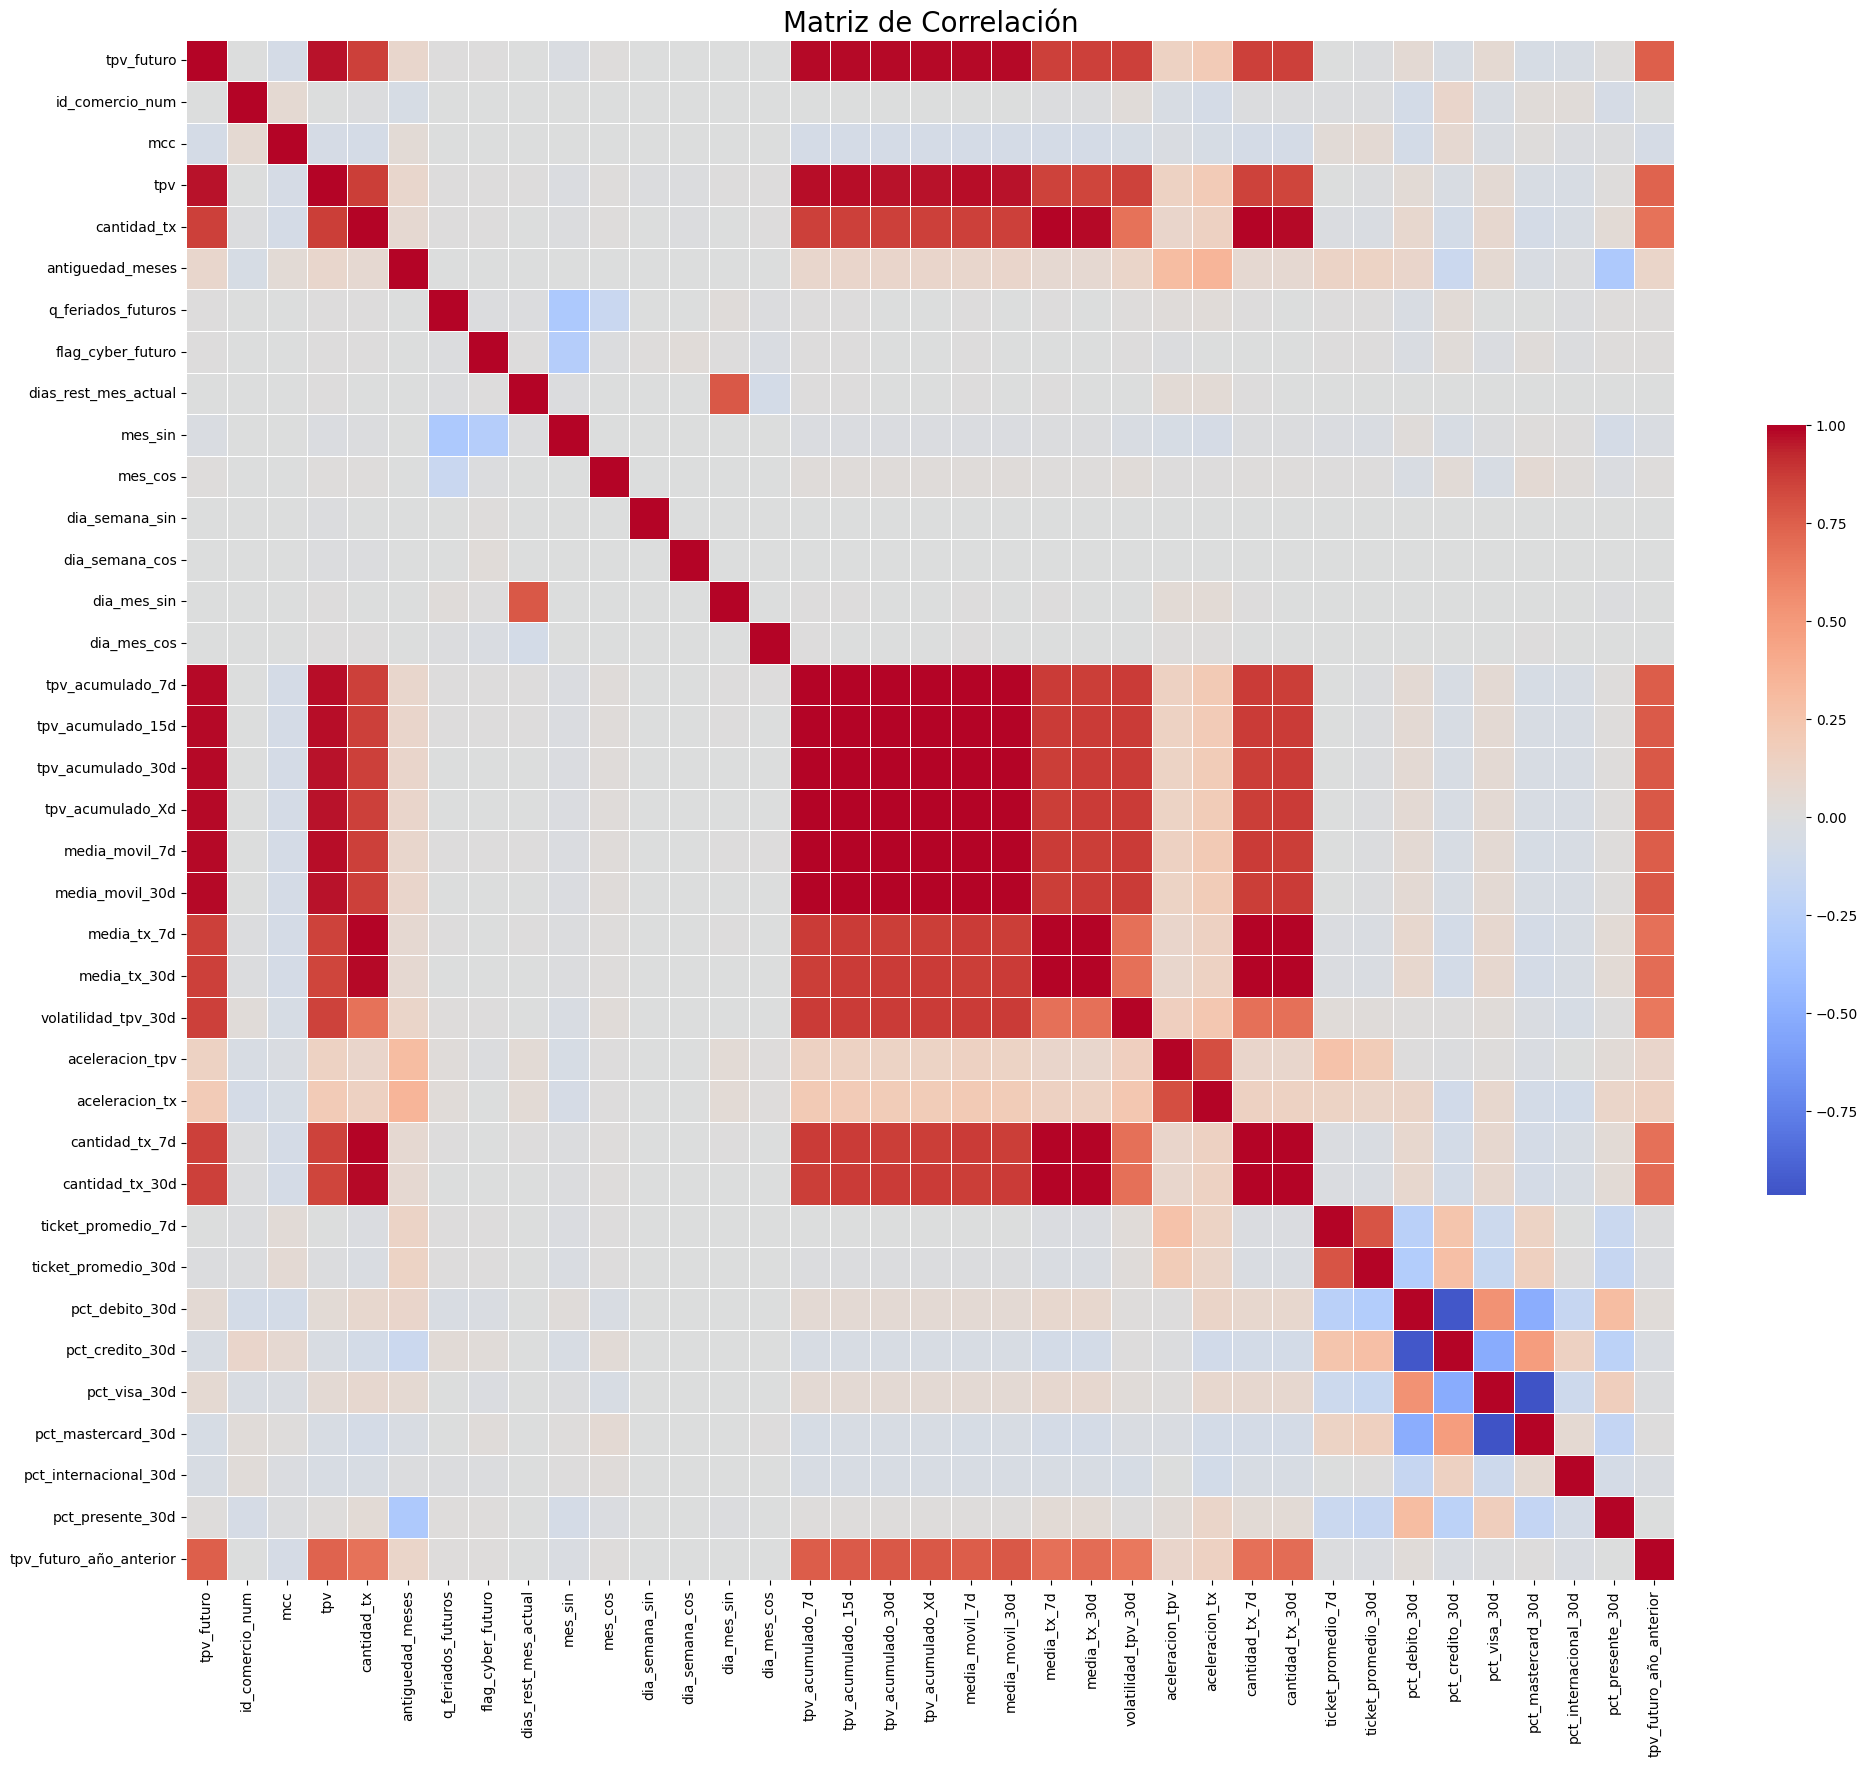

In [31]:
# Reordenar columnas para que 'tpv_futuro' sea la primera
cols = df_final.columns.tolist()
target = 'tpv_futuro'

# Si el target existe en las columnas, lo movemos al principio
if target in cols:
    cols.remove(target)
    cols.insert(0, target)
    
    # Creamos un nuevo DF con el orden deseado
    df_reordenado = df_final[cols]
else:
    print(f"No se encontró la columna '{target}'. Usando orden original.")
    df_reordenado = df_final

# Calcular la matriz de correlación sobre el DF ordenado
corr_matrix = df_reordenado.corr(numeric_only=True)

# Graficar
plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix, 
    annot=False,        # Sin números para limpieza visual
    cmap='coolwarm',    # Rojo=Positiva, Azul=Negativa
    center=0, 
    linewidths=0.5,
    cbar_kws={"shrink": .5}
)

plt.title('Matriz de Correlación', fontsize=20)
# Rotamos las etiquetas para que se lean bien
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10, rotation=0)

plt.show()

Aquí va el resto del EDA (si tuviera uno...)

## Entrenamiento

### Preparación dataset entrenamiento y validación

In [32]:
def preparar_datos(df, target_col='tpv_futuro'):
    
    # Eliminar fecha y target de Features
    cols_drop = ['fecha_trx', target_col]
    
    # Crear features y target
    X = df.drop(columns=cols_drop)
    y = df[target_col]
    
    return X, y

### Función de callback por comodidad

In [33]:
from tqdm.notebook import tqdm
# Callback personalizado, muestra estado actual de entrenamiento con barra de progreso y métricas en tiempo real
def callback_barra_progreso(total_iteraciones):
    # Creamos la barra de progreso con tqdm
    # desc: descripción que se muestra, unit: unidad de medida, leave=False para que no deje la barra al finalizar
    pbar = tqdm(total=total_iteraciones, desc="Entrenando", unit="iter", leave=False) 
    
    def _callback(env):
        pbar.update(1)
        
        # Métricas en tiempo real
        if env.evaluation_result_list:
            # Asumiendo que validation es el segundo elemento (index 1)
            # Si solo tienes train, usa index 0
            val_rmse = env.evaluation_result_list[1][2]
            pbar.set_postfix({'Val RMSE': f'{val_rmse:,.0f}'})
        
        if env.iteration + 1 == env.end_iteration:
            pbar.close()
            
    _callback.order = 10
    return _callback

### Entrenamiento modelos

IMPORTANTE: Eliminar comercios que podrían estar sesgando el modelo general. Revisar bien el comportamiento e historia de los comercios para que el modelo global quede bien entrenado.

#### Definir hiperparámetros

In [34]:
# Cantidad de iteraciones para entrenamiento.
# Considerar aumentar para entrenamiento simple, pero no para aplicar Optuna ni para backtesting.
Iters = 10000 # Original: 10000

# Parámetros para el modelo general (todos los comercios juntos)

# Parámetros para el modelo que busca un buen balance entre under/overestimation
# Este modelo es el que mejor lee el TPV global para el modelo que excluye comercios, aunque subestima o sobreestima
# algunos comercios específicos.
params_lgb_gen = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.0,
    'metric': 'rmse',
    'num_leaves': 256,
    'max_depth': -1,
    'min_data_in_leaf': 50,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'min_gain_to_split': 0.0,
    'learning_rate': 0.03,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.9,
    'bagging_freq': 1,
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'n_jobs': -1,
    'seed': 42
}

# Parámetros para el modelo que lee bien los comercios en general pero los subestima
# params_lgb_gen = {
#     'objective': 'tweedie',
#     'tweedie_variance_power': 1.2,
#     'metric': 'rmse',
#     'num_leaves': 128,
#     'max_depth': -1,
#     'min_data_in_leaf': 100,
#     'lambda_l1': 1.0,
#     'lambda_l2': 2.0,
#     'min_gain_to_split': 0.1,
#     'learning_rate': 0.03,
#     'feature_fraction': 0.4,
#     'bagging_fraction': 0.8,
#     'bagging_freq': 1,
#     'boosting_type': 'gbdt',
#     'verbosity': -1,
#     'n_jobs': -1,
#     'seed': 42
# }

# Parámetros para el modelo de cada comercio individual
params_lgb_ind = {
    'objective': 'tweedie',
    'tweedie_variance_power': 1.6, 
    'metric': 'rmse',
    'num_leaves': 15,
    'max_depth': 4,
    'min_data_in_leaf': 15,
    'lambda_l1': 0.2,
    'lambda_l2': 2.0,
    'min_gain_to_split': 0.0,
    'boosting_type': 'gbdt',
    'learning_rate': 0.02,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.7,
    'bagging_freq': 1,
    'verbosity': -1,
    'n_jobs': 1, # no cambiar
    'seed': 42
}

In [35]:
# Función objetivo para Optuna, optimiza hiperparámetros de LightGBM con pruning inteligente
# Esto es una alternativa a la búsqueda manual de hiperparámetros,
# pero requiere de mucho más tiempo de entrenamiento.
def objetivo_optuna(trial, train_data, val_data, X_val, y_val):
    
    # Definir el Espacio de Búsqueda
    # Estos son los rangos donde Optuna buscará la mejor combinación, es bueno tener una idea inicial.
    params = {
        # Primero los parámetros fijos que no se optimizan, para mantener la coherencia con el modelo general
        'objective': 'tweedie', # Siempre tweedie para manejar la naturaleza tendenciosa y con colas del TPV
        'metric': 'rmse', # RMSE es la métrica principal para optimizar, aunque también se podría considerar R2 o MAE
        'verbosity': -1, # Silenciar logs para no saturar la salida durante la optimización
        'boosting_type': 'gbdt', # Gradient Boosting tradicional, aunque también se podría probar 'dart' o 'goss' en una etapa posterior
        'seed': 42, # Semilla para reproducibilidad
        'n_jobs': -1, # Usar todos los núcleos disponibles del sistema para acelerar el entrenamiento
        
        'feature_pre_filter': False, # Desactivar pre-filtering para que el modelo pueda considerar todas las features, aunque algunas tengan baja importancia inicial

        # Parámetros a optimizar:
        # Tweedie Power: Entre 1.0 (Poisson) y 1.9 (Gamma). 
        # Valores bajos (1.0-1.2) ayudan a no subestimar grandes comercios.
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.0, 1.5),
        
        # Regularización: Clave para controlar si el modelo es conservador o agresivo
        'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 5.0), # L1 ayuda a reducir la importancia de features menos relevantes, lo que puede ser útil para evitar overfitting
        'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 5.0), # L2 ayuda a reducir la magnitud de los pesos, lo que también puede ayudar a evitar overfitting
        
        # Estructura del árbol
        'num_leaves': trial.suggest_int('num_leaves', 31, 512), # Número de hojas en cada árbol, controla la complejidad del modelo
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 200), # Número mínimo de datos en cada hoja, ayuda a evitar overfitting en ramas con pocos datos
        'max_depth': trial.suggest_int('max_depth', -1, 15), # Profundidad máxima del árbol, -1 significa sin límite, pero limitarlo puede ayudar a evitar overfitting
        
        # Aprendizaje
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 0.9), # Fracción de features a considerar en cada iteración, ayuda a reducir overfitting
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 0.9), # Fracción de datos a usar en cada iteración, ayuda a reducir overfitting
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7), # Frecuencia de bagging, controla cada cuántas iteraciones se aplica el bagging
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1) # Tasa de aprendizaje, controla qué tan rápido se ajusta el modelo a los datos
    }
    
    # Callbacks Inteligentes (Pruning)
    # Esto corta el entrenamiento si va mal. Ahorra mucho tiempo.
    pruning_callback = LightGBMPruningCallback(trial, "rmse")
    
    # Entrenar Modelo
    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=1000, # Damos espacio, pero el pruning cortará antes si es necesario
        callbacks=[pruning_callback, lgb.early_stopping(50, verbose=False)]
    )
    
    # Evaluar y Retornar Error
    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)
    rmse = np.sqrt(mse)
    
    return rmse

#### Modelo Global

Modelo entrenado con toda la data, es decir, modelo único para todos los comercios

##### Función de entrenamiento

In [36]:
def entrenar_modelo_global(df_final, fecha_corte, encoder=None, iters=Iters, dias_val=dias_pred, dias_benchmark=7, plotear=False, verbose=True, usar_optuna=False, exportar=False):
    """
    Entrena un modelo global usando LightGBM con una configuración de corte temporal que incluye un gap de seguridad
    que viene dado por los días que no se pueden usar para testear debido a la lógica temporal del problema.
    Parámetros:
    - df_final: DataFrame con las features generadas y el target.
    - fecha_corte: Fecha de corte para definir la ventana de test (formato 'YYYY-MM-DD').
    - encoder: Encoder de nombres de comercio (opcional, no se usa directamente aquí pero se pasa por si se necesita para futuras transformaciones).
    - iters: Número máximo de iteraciones para LightGBM.
    - dias_val: Número de días para la validación.
    - dias_benchmark: Número de días para test (benchmark).
    - plotear: Si es True, muestra gráficos de importancia de features.
    - verbose: Si es True, muestra información detallada durante el proceso.
    - usar_optuna: Si es True, realiza optimización de hiperparámetros con Optuna.
    Retorna:
    - model: El modelo entrenado de LightGBM.
    - df_test: DataFrame con las filas de test y sus predicciones.
    - y_test: Valores reales del target para el test.
    - y_pred: Predicciones del modelo para el test.
    - exportar: Si es True, exporta los resultados a un archivo CSV.
    """
    # Configuración de Fechas
    fecha_corte_test = pd.to_datetime(fecha_corte)
    
    # Definir la Ventana de Test
    # fecha_corte_test es el último día del período de test
    fecha_inicio_test = fecha_corte_test - pd.Timedelta(days=dias_benchmark - 1)
    fecha_fin_test = fecha_corte_test
    
    # GAP DE SEGURIDAD
    # Retrocedemos dias_val días desde el inicio del Test. Esto pues si quisieramos predecir
    # el día x, entonces no podríamos usar datos del día x-1, x-2, ..., x-dias_val para entrenar.
    fecha_limite_entrenamiento = fecha_inicio_test - pd.Timedelta(days=dias_val)
    
    # Definir Validación y Train respecto a ese límite
    # Validación: El mes previo al Gap
    fecha_inicio_val = fecha_limite_entrenamiento - pd.Timedelta(days=dias_val)
    max_fecha_dataset = df_final['fecha_trx'].max()
    
    if max_fecha_dataset < fecha_fin_test:
        if verbose:
            print(f"Error: Horizonte de datos insuficiente.")
            print(f"El dataset llega hasta: {max_fecha_dataset.date()}")
            print(f"Se requiere testear hasta: {fecha_fin_test.date()}")
            print(f"Faltan {(fecha_fin_test - max_fecha_dataset).days} días de datos reales.")
        return None, None, None, None
    
    # Verificación de fechas
    if verbose:
        print(f"Test        : {fecha_inicio_test.date()} al {fecha_fin_test.date()}")
        print(f"Gap         : {fecha_limite_entrenamiento.date()} al {fecha_inicio_test.date()} ({dias_val} días)")
        print(f"Validación  : {fecha_inicio_val.date()} al {fecha_limite_entrenamiento.date()}")
        print(f"Train       : Inicio hasta {fecha_inicio_val.date()}")

    # Cortes Temporales

    # TRAIN: Todo antes de validación
    mask_train = df_final['fecha_trx'] < fecha_inicio_val
    
    # VAL: Desde inicio val hasta el límite del Gap
    mask_val = (df_final['fecha_trx'] >= fecha_inicio_val) & (df_final['fecha_trx'] < fecha_limite_entrenamiento)
    
    # TEST: La ventana de prueba
    mask_test = (df_final['fecha_trx'] >= fecha_inicio_test) & (df_final['fecha_trx'] <= fecha_fin_test)
    
    df_train = df_final[mask_train]
    df_val   = df_final[mask_val]
    df_test  = df_final[mask_test].copy()
    
    if len(df_test) == 0:
        if verbose: print("Error: No hay filas para el rango de test.")
        return None, None, None, None

    if verbose:
        print(f"Filas Train: {len(df_train)}")
        print(f"Filas Val  : {len(df_val)}")
        print(f"Filas Test : {len(df_test)}")

    # Preparar Matrices
    X_train, y_train = preparar_datos(df_train)
    X_val, y_val     = preparar_datos(df_val)
    X_test, y_test   = preparar_datos(df_test)
    
    # Alineación de índices para Test
    df_test = df_test.loc[X_test.index].copy()

    # Configurar LightGBM
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data   = lgb.Dataset(X_val, label=y_val, reference=train_data)

    ITERACIONES = iters

    mis_params = params_lgb_gen.copy() # Por defecto usamos los fijos
    
    # Optimización de hiperparámetros con Optuna
    if usar_optuna:
        if verbose: print("\nIniciando Optimización con Optuna (10 Trials)")

        optuna.logging.set_verbosity(optuna.logging.INFO)
        
        # Función lambda para pasar los datos fijos a la función objetivo
        func_objetivo = lambda trial: objetivo_optuna(trial, train_data, val_data, X_val, y_val)
        
        # Crear estudio y optimizar
        study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
        study.optimize(func_objetivo, n_trials=10) # 10 intentos es un buen balance rápido/bueno

        clear_output(wait=True) # Limpiar logs de Optuna para no saturar la salida
        
        if verbose:
            print(f"Mejores parámetros encontrados: {study.best_params}")
            print(f"Mejor RMSE en validación: {study.best_value:,.0f}")
        
        # Actualizamos los parámetros con los ganadores
        mis_params.update(study.best_params)
    
    mis_callbacks = [
        lgb.early_stopping(stopping_rounds=1000, verbose=False),
        callback_barra_progreso(ITERACIONES)
    ]

    # Entrenar
    model = lgb.train(
        params=mis_params,
        train_set=train_data,
        valid_sets=[train_data, val_data],
        valid_names=['TRAIN', 'VALIDATION'],
        num_boost_round=ITERACIONES,
        callbacks=mis_callbacks
    )

    # Exportar modelo si se desea
    if exportar:
        RUTA_MODELOS = Path('../data/modelos')
        RUTA_MODELOS.mkdir(parents=True, exist_ok=True)
        
        # Nombre del archivo con la fecha de corte para versionado
        nombre_archivo = f"lgbm_global_{fecha_corte}_{dias_pred}dias.txt"
        ruta_completa = RUTA_MODELOS / nombre_archivo
        
        if verbose:
            print(f"\n[EXPORT] Guardando modelo en: {ruta_completa}")
        
        model.save_model(str(ruta_completa))


    
    # Evaluar en Test
    y_pred = model.predict(X_test, num_iteration=model.best_iteration)
    
    # Guardamos predicción en el df
    df_test['prediccion_mcc'] = y_pred

    # Resultados Globales
    if verbose:
        print(f"\nResultados Globales")
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        print(f"RMSE Global: {rmse:,.2f}")
        print(f"R2 Global  : {r2:.4f}")
        print(f"TPV total real    : ${y_test.sum():,.0f}")
        print(f"TPV total predicho: ${y_pred.sum():,.0f}")
    
    # Visualizaciones
    if plotear:
        # Importancia de Features porcentual
        importancia = model.feature_importance(importance_type='gain')
        nombres = model.feature_name()
        df_imp = pd.DataFrame({'feature': nombres, 'gain': importancia})
        df_imp['percent'] = (df_imp['gain'] / df_imp['gain'].sum()) * 100
        df_imp = df_imp.sort_values('percent', ascending=True).tail(15)

        plt.figure(figsize=(10, 6))
        barras = plt.barh(df_imp['feature'], df_imp['percent'], color='#1f77b4')
        plt.xlabel('Importancia Relativa (%)')
        plt.title(f'Importancia de Features del Modelo')
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        for bar in barras:
            plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%', va='center', fontsize=9)
        plt.tight_layout()
        plt.show()
        
        col_target = 'tpv_futuro'
        
        # Resultados Día 1 de Test
        print(f"\nDía 1 de test ({fecha_inicio_test.date()})")
        
        # Filtramos solo el primer día
        df_dia1 = df_test[df_test['fecha_trx'] == fecha_inicio_test].copy()
        
        if len(df_dia1) > 0:
            df_grouped_d1 = df_dia1.groupby('id_comercio_num')[[col_target, 'prediccion_mcc']].sum().reset_index()
            df_grouped_d1.rename(columns={col_target: 'Real Total', 'prediccion_mcc': 'Pred Total'}, inplace=True)
            
            if encoder:
                try: df_grouped_d1['Comercio'] = encoder.inverse_transform(df_grouped_d1['id_comercio_num'].astype(int))
                except: df_grouped_d1['Comercio'] = "ID_" + df_grouped_d1['id_comercio_num'].astype(str)
            else:
                df_grouped_d1['Comercio'] = "ID_" + df_grouped_d1['id_comercio_num'].astype(str)

            df_grouped_d1['Diff'] = df_grouped_d1['Real Total'] - df_grouped_d1['Pred Total']
            df_grouped_d1['Error (%)'] = (df_grouped_d1['Diff'].abs() / df_grouped_d1['Real Total']) * 100
            df_grouped_d1 = df_grouped_d1.sort_values('Diff', key=abs, ascending=False)
            
            # WMAPE Día 1
            wmape_d1 = df_grouped_d1['Diff'].abs().sum() / df_grouped_d1['Real Total'].sum()
            print(f"WMAPE Día 1: {wmape_d1:.2%}")

            cols_show = ['Comercio', 'Real Total', 'Pred Total', 'Diff', 'Error (%)']
            fmt = {'Real Total': '${:,.0f}'.format, 'Pred Total': '${:,.0f}'.format, 'Diff': '${:,.0f}'.format, 'Error (%)': '{:.2f}%'.format}
            display(HTML(f"""<div style="max-height: 300px; overflow-y: auto;">{df_grouped_d1[cols_show].to_html(formatters=fmt, index=False, classes='table table-striped')}</div>"""))
        
        # Resultados día 7 de Test
        print(f"\nDía 7 de test ({fecha_fin_test.date()})")
        df_dia7 = df_test[df_test['fecha_trx'] == fecha_fin_test].copy()
        if len(df_dia7) > 0:
            df_grouped_d7 = df_dia7.groupby('id_comercio_num')[[col_target, 'prediccion_mcc']].sum().reset_index()
            df_grouped_d7.rename(columns={col_target: 'Real Total', 'prediccion_mcc': 'Pred Total'}, inplace=True)
            
            if encoder:
                try: df_grouped_d7['Comercio'] = encoder.inverse_transform(df_grouped_d7['id_comercio_num'].astype(int))
                except: df_grouped_d7['Comercio'] = "ID_" + df_grouped_d7['id_comercio_num'].astype(str)
            else:
                df_grouped_d7['Comercio'] = "ID_" + df_grouped_d7['id_comercio_num'].astype(str)

            df_grouped_d7['Diff'] = df_grouped_d7['Real Total'] - df_grouped_d7['Pred Total']
            df_grouped_d7['Error (%)'] = (df_grouped_d7['Diff'].abs() / df_grouped_d7['Real Total']) * 100
            df_grouped_d7 = df_grouped_d7.sort_values('Diff', key=abs, ascending=False)
            
            # WMAPE Día 7
            wmape_d7 = df_grouped_d7['Diff'].abs().sum() / df_grouped_d7['Real Total'].sum()
            print(f"WMAPE Día 7: {wmape_d7:.2%}")

            cols_show = ['Comercio', 'Real Total', 'Pred Total', 'Diff', 'Error (%)']
            fmt = {'Real Total': '${:,.0f}'.format, 'Pred Total': '${:,.0f}'.format, 'Diff': '${:,.0f}'.format, 'Error (%)': '{:.2f}%'.format}
            display(HTML(f"""<div style="max-height: 300px; overflow-y: auto;">{df_grouped_d7[cols_show].to_html(formatters=fmt, index=False, classes='table table-striped')}</div>"""))


        # Benchmark (Promedio de % error diario, en general funciona mejor que solo mirar el error del día 1 o del día 7, pues suaviza las fluctuaciones diarias y da una visión más general del desempeño durante toda la ventana de test)
        print(f"\nBenchmark (Promedio Error % en {dias_benchmark} días)")
        
        # Agrupar por CLIENTE y FECHA (Sumamos MCCs para tener el total diario de cada cliente)
        df_daily = df_test.groupby(['id_comercio_num', 'fecha_trx'])[[col_target, 'prediccion_mcc']].sum().reset_index()
        
        # Calcular Error % DIARIO para cada cliente
        df_daily['error_abs'] = (df_daily[col_target] - df_daily['prediccion_mcc']).abs()
        df_daily['error_pct_diario'] = (df_daily['error_abs'] / df_daily[col_target]) * 100
        df_daily['error_pct_diario'] = df_daily['error_pct_diario'].replace([np.inf, -np.inf], 0).fillna(0)
        
        # Agrupar por CLIENTE para sacar el PROMEDIO del periodo
        df_benchmark = df_daily.groupby('id_comercio_num').agg({
            col_target: 'sum',           # Suma total real del periodo (para referencia)
            'prediccion_mcc': 'sum',     # Suma total predicha del periodo
            'error_pct_diario': 'mean',  # Promedio del error % diario
            'error_abs': 'sum'
        }).reset_index()
        
        # WMAPE GLOBAL
        wmape_week = df_benchmark['error_abs'].sum() / df_benchmark[col_target].sum()
        print(f"WMAPE Global: {wmape_week:.2%}")
        
        # Obtener nombres de comercio
        if encoder:
            try: df_benchmark['Comercio'] = encoder.inverse_transform(df_benchmark['id_comercio_num'].astype(int))
            except: df_benchmark['Comercio'] = "ID_" + df_benchmark['id_comercio_num'].astype(str)
        else:
            df_benchmark['Comercio'] = "ID_" + df_benchmark['id_comercio_num'].astype(str)
            
        df_benchmark = df_benchmark.sort_values('error_pct_diario', ascending=True)
        
        cols_bench = ['Comercio', col_target, 'prediccion_mcc', 'error_pct_diario']
        df_display = df_benchmark[cols_bench].copy()
        df_display.columns = ['Comercio', 'Real Acum. Periodo', 'Pred Acum. Periodo', 'Promedio Error % Diario']
        
        fmt_bench = {
            'Real Acum. Periodo': '${:,.0f}'.format,
            'Pred Acum. Periodo': '${:,.0f}'.format,
            'Promedio Error % Diario': '{:.2f}%'.format
        }
        
        display(HTML(f"""<div style="max-height: 400px; overflow-y: auto;">{df_display.to_html(formatters=fmt_bench, index=False, classes='table table-striped')}</div>"""))
        
    return model, df_test, X_test, y_test

##### Ejemplo ejecución simple

In [37]:
# Ejecución de ejemplo
# Probamos predecir el comportamiento desde una fecha cualquiera
# Probar distintos meses y días para ver cómo se comporta el modelo
fecha_test = '2025-08-01'

model, df_test, X_test, y_test = entrenar_modelo_global(df_final, fecha_test, encoder=encoder, plotear=True, verbose=True, iters=Iters, usar_optuna=True)

[I 2026-02-24 01:02:13,141] A new study created in memory with name: no-name-6ce0f22a-3661-473a-a61f-5c86acf510ac


Test        : 2025-07-26 al 2025-08-01
Gap         : 2025-06-28 al 2025-07-26 (28 días)
Validación  : 2025-05-31 al 2025-06-28
Train       : Inicio hasta 2025-05-31
Filas Train: 745108
Filas Val  : 16744
Filas Test : 4186

Iniciando Optimización con Optuna (10 Trials)


[W 2026-02-24 01:02:18,242] Trial 0 failed with parameters: {'tweedie_variance_power': 1.1904535525889475, 'lambda_l1': 4.625586592395946, 'lambda_l2': 0.6125344665586441, 'num_leaves': 468, 'min_data_in_leaf': 62, 'max_depth': 0, 'feature_fraction': 0.5450033683321103, 'bagging_fraction': 0.6762300335410011, 'bagging_freq': 7, 'learning_rate': 0.04238583410829894} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\urbin\AppData\Local\Programs\Python\Python313\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\urbin\AppData\Local\Temp\ipykernel_28940\609632208.py", line 102, in <lambda>
    func_objetivo = lambda trial: objetivo_optuna(trial, train_data, val_data, X_val, y_val)
                                  ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\urbin\AppData\Local\Temp\ipykernel_28940\3353039575.py", line 45, in objetivo_o

KeyboardInterrupt: 

##### Benchmarking (backtesting)

In [ ]:
# Mapeo de meses
MESES_ESP = {
    1: 'ENE', 2: 'FEB', 3: 'MAR', 4: 'ABR', 5: 'MAY', 6: 'JUN',
    7: 'JUL', 8: 'AGO', 9: 'SEP', 10: 'OCT', 11: 'NOV', 12: 'DIC'
}

def generar_reporte(df, filename, tipo_reporte='porcentual'):
    """
    Genera reporte PDF para el backtesting de los modelos.
    Args:
    - df: DataFrame con las columnas de comercio, errores y métricas.
    - filename: Nombre del archivo PDF a generar.
    - tipo_reporte: 'porcentual' para errores con signo en %, 'cantidad' para diferencias en miles de millones (B).
    """
    # Preparación del DataFrame
    df_print = df.copy()
    
    # Eliminar columnas internas de ordenamiento
    cols_drop = ['id_comercio_num', 'Total_Abs_Diff'] 
    for c in cols_drop:
        if c in df_print.columns: df_print.drop(columns=[c], inplace=True)

    # Renombrar columnas para el reporte
    new_columns = {}
    col_date_map = {} 
    
    for col in df_print.columns:
        if col.startswith('err_') or col.startswith('diff_'):
            try:
                date_part = col.replace('err_', '').replace('diff_', '')
                dt = pd.to_datetime(date_part)
                mes_nombre = MESES_ESP[dt.month]
                new_columns[col] = mes_nombre
                col_date_map[mes_nombre] = dt
            except:
                new_columns[col] = col
                
        elif 'nombre_comercio' in col:
            new_columns[col] = 'COMERCIO'
        elif 'Promedio_Error_Global' in col: 
            new_columns[col] = 'PROM'
        elif 'Promedio_Abs_Global' in col: 
            new_columns[col] = 'PROM ABS'
            
    df_print.rename(columns=new_columns, inplace=True)
    
    # Reordenar columnas: COMERCIO al inicio, luego meses ordenados cronológicamente, y métricas al final
    final_order = ['COMERCIO']
    
    # Meses ordenados cronológicamente
    meses_cols = [c for c in df_print.columns if c in col_date_map]
    meses_ordenados = sorted(meses_cols, key=lambda x: col_date_map[x])
    final_order.extend(meses_ordenados)
    
    # Métricas al final: PROM y luego PROM ABS
    if 'PROM' in df_print.columns:
        final_order.append('PROM')
    if 'PROM ABS' in df_print.columns:
        final_order.append('PROM ABS')
        
    # Filtrar solo columnas existentes
    final_order = [c for c in final_order if c in df_print.columns]
    df_print = df_print[final_order]

    # Formateo de valores
    for col in df_print.columns:
        if col != 'COMERCIO':
            if tipo_reporte == 'porcentual':
                # Porcentaje con signo y un decimal
                df_print[col] = df_print[col].apply(lambda x: f"{x:+.1f}%" if isinstance(x, (int, float)) else x)
            elif tipo_reporte == 'cantidad':
                # Miles de Millones con signo y con 1 decimal
                df_print[col] = df_print[col].apply(lambda x: f"{x/1e9:+.1f}B" if isinstance(x, (int, float)) else x)

    # Diseño
    n_cols = len(df_print.columns)
    col_width_name = 0.22 
    col_width_metric = (1.0 - col_width_name) / (n_cols - 1)
    col_widths = [col_width_name] + [col_width_metric] * (n_cols - 1)
    
    # Colores
    header_color = '#2980b9' if tipo_reporte == 'porcentual' else '#27ae60' 
    total_row_color = '#2c3e50'
    row_colors = ['#ecf0f1', '#ffffff']
    text_color_header = 'white'
    edge_color = '#bdc3c7'

    # PDF Loop

    # Esto no debería ser necesario porque son menos de 30 filas, pero por si acaso si
    # a futuro se agregan más comercios
    rows_per_page = 30
    total_rows = len(df_print)
    pages = (total_rows // rows_per_page) + 1
    
    with PdfPages(filename) as pdf:
        for page in range(pages):
            start = page * rows_per_page
            end = start + rows_per_page
            chunk = df_print.iloc[start:end]
            
            if chunk.empty: break
            
            fig, ax = plt.subplots(figsize=(11.69, 8.27))
            ax.axis('tight')
            ax.axis('off')
            
            subtit = "(Error Porcentual)" if tipo_reporte == 'porcentual' else "(Diferencia en MM $)"
            title = f"Reporte Backtesting Global {subtit} - Pág {page+1}/{pages}"
            plt.title(title, fontsize=12, color='#2c3e50', loc='left', pad=15)
            
            table_data = [chunk.columns.to_list()] + chunk.values.tolist()
            
            table = ax.table(
                cellText=table_data,
                colWidths=col_widths,
                loc='center',
                cellLoc='center'
            )
            
            table.auto_set_font_size(False)
            table.set_fontsize(8)
            table.scale(1, 1.3)
            
            for (row, col), cell in table.get_celld().items():
                cell.set_edgecolor(edge_color)
                cell.set_linewidth(0.5)
                
                if row == 0: # Header
                    cell.set_text_props(weight='bold', color=text_color_header)
                    cell.set_facecolor(header_color)
                    cell.set_height(0.06)
                else:
                    cell_value = chunk.iloc[row-1, 0] 
                    is_total = (cell_value == 'TOTAL')
                    
                    if is_total:
                        cell.set_facecolor(total_row_color)
                        cell.set_text_props(weight='bold', color='white')
                        cell.set_height(0.05)
                    else:
                        cell.set_facecolor(row_colors[row % 2])
                        cell.set_height(0.04)
                    
                    col_name = chunk.columns[col]
                    
                    # Alineación
                    if col == 0:
                        cell.set_text_props(ha='left' if not is_total else 'center')
                        if not is_total: cell._loc = 'left'
                    else:
                        cell.set_text_props(ha='center')
                        
                        # Destacar columnas PROM y PROM ABS
                        if col_name == 'PROM' and not is_total:
                            cell.set_text_props(weight='bold')
                            cell.set_facecolor("#e3e9e9")
                        elif col_name == 'PROM ABS' and not is_total:
                            cell.set_text_props(weight='bold')
                            cell.set_facecolor("#ecfdfb")

            pdf.savefig(fig, bbox_inches='tight', pad_inches=0.4)
            plt.close()

In [16]:
def ejecutar_backtesting_global(df_final, fechas_corte, encoder, dias_testeo=dias_pred, dias_benchmark=7):
    
    lista_pct = []    
    lista_monto = []  
    totales_por_fecha = {} 
    
    pbar = tqdm(fechas_corte, desc="Backtesting Global")
    
    for fecha in pbar:
        try:
            pbar.set_postfix({'status': f'Procesando {fecha}...'})
            model, df_test, _, _ = entrenar_modelo_global(
                df_final, fecha_corte=fecha, encoder=encoder,
                dias_val=dias_testeo, dias_benchmark=dias_benchmark, plotear=False, verbose=False, usar_optuna=True
            )
        except Exception as e:
            tqdm.write(f"Error en fecha {fecha}: {e}")
            continue
            
        if model is None: continue

        # Datos diarios por comercio para el período de test
        df_daily = df_test.groupby(['id_comercio_num', 'fecha_trx'])[['tpv_futuro', 'prediccion_mcc']].sum().reset_index()
        df_daily['diff_monto'] = df_daily['prediccion_mcc'] - df_daily['tpv_futuro']
        df_daily['diff_pct'] = (df_daily['diff_monto'] / df_daily['tpv_futuro'].replace(0, np.nan)) * 100
        df_daily['diff_pct'] = df_daily['diff_pct'].fillna(0)
        
        # Totales globales para el período de test
        tpv_real = df_test['tpv_futuro'].sum()
        tpv_pred = df_test['prediccion_mcc'].sum()
        col_suffix = pd.to_datetime(fecha).strftime('%Y-%m-%d')
        totales_por_fecha[col_suffix] = {'real': tpv_real, 'pred': tpv_pred}

        # Tabla de resultados por comercio para este corte temporal
        # Porcentual (con signo)
        df_pct = df_daily.groupby('id_comercio_num')['diff_pct'].mean().reset_index()
        lista_pct.append(df_pct.rename(columns={'diff_pct': f"err_{col_suffix}"}))
        
        # Monto (con signo)
        df_monto = df_daily.groupby('id_comercio_num')['diff_monto'].mean().reset_index()
        lista_monto.append(df_monto.rename(columns={'diff_monto': f"diff_{col_suffix}"}))
        
        del model, df_test, df_daily, df_pct, df_monto
        gc.collect() 

    if not lista_pct:
        print("No se generaron resultados.")
        return None
        
    tqdm.write("Consolidando matrices...")
    df_matrix_pct = reduce(lambda left, right: pd.merge(left, right, on='id_comercio_num', how='outer'), lista_pct)
    df_matrix_monto = reduce(lambda left, right: pd.merge(left, right, on='id_comercio_num', how='outer'), lista_monto)
    
    # Nombres
    def agregar_nombres(df):
        if encoder:
            try: df['nombre_comercio'] = encoder.inverse_transform(df['id_comercio_num'].astype(int))
            except: df['nombre_comercio'] = "ID_" + df['id_comercio_num'].astype(str)
        else:
            df['nombre_comercio'] = "ID_" + df['id_comercio_num'].astype(str)
        return df

    df_matrix_pct = agregar_nombres(df_matrix_pct)
    df_matrix_monto = agregar_nombres(df_matrix_monto)
    
    # Orden Columnas
    cols_pct = [c for c in df_matrix_pct.columns if c.startswith('err_')]
    df_matrix_pct = df_matrix_pct[['id_comercio_num', 'nombre_comercio'] + cols_pct]
    
    cols_monto = [c for c in df_matrix_monto.columns if c.startswith('diff_')]
    df_matrix_monto = df_matrix_monto[['id_comercio_num', 'nombre_comercio'] + cols_monto]
    
    # Fila Total
    tqdm.write("Calculando fila Total...")
    fila_total_pct = {'id_comercio_num': -999, 'nombre_comercio': 'TOTAL'}
    fila_total_monto = {'id_comercio_num': -999, 'nombre_comercio': 'TOTAL'}
    
    vals_total_pct = []
    vals_total_monto = []
    
    for suffix, data in totales_por_fecha.items():
        diff = data['pred'] - data['real']
        diff_prom = diff / 7
        fila_total_monto[f"diff_{suffix}"] = diff_prom
        vals_total_monto.append(diff_prom)
        
        pct = (diff / data['real'] * 100) if data['real'] > 0 else 0
        fila_total_pct[f"err_{suffix}"] = pct
        vals_total_pct.append(pct)

    # Promedios
    
    # Tabla Porcentual
    # PROM: Promedio simple (con signo)
    df_matrix_pct['Promedio_Error_Global'] = df_matrix_pct[cols_pct].mean(axis=1)
    fila_total_pct['Promedio_Error_Global'] = np.mean(vals_total_pct)
    
    # PROM ABS: Promedio de los valores absolutos
    df_matrix_pct['Promedio_Abs_Global'] = df_matrix_pct[cols_pct].abs().mean(axis=1)
    fila_total_pct['Promedio_Abs_Global'] = np.mean([abs(x) for x in vals_total_pct])
    
    # Tabla Monto
    df_matrix_monto['Promedio_Error_Global'] = df_matrix_monto[cols_monto].mean(axis=1)
    fila_total_monto['Promedio_Error_Global'] = np.mean(vals_total_monto)

    # Ordenar resultados
    # Porcentual: Ordenar por PROM ABS Ascendente (Menor error magnitud)
    df_final_pct = df_matrix_pct.sort_values('Promedio_Abs_Global', ascending=True)
    
    # Monto: Ordenar por Impacto Absoluto Descendente
    df_matrix_monto['Total_Abs_Diff'] = df_matrix_monto[cols_monto].abs().sum(axis=1)
    df_final_monto = df_matrix_monto.sort_values('Total_Abs_Diff', ascending=False)
    
    # Pegar fila total al final
    df_final_pct = pd.concat([df_final_pct, pd.DataFrame([fila_total_pct])], ignore_index=True)
    df_final_monto = pd.concat([df_final_monto, pd.DataFrame([fila_total_monto])], ignore_index=True)
    
    # Generar PDFs
    tqdm.write("Generando PDFs...")
    os.makedirs('models', exist_ok=True)
    
    ruta_pct = 'models/backtesting_global_lgb_porcentual.pdf'
    generar_reporte(df_final_pct, ruta_pct, tipo_reporte='porcentual')
    print(f"Reporte Porcentual: {ruta_pct}")
        
    ruta_cant = 'models/backtesting_global_lgb_cantidad.pdf'
    generar_reporte(df_final_monto, ruta_cant, tipo_reporte='cantidad')
    print(f"Reporte Cantidad: {ruta_cant}")
    
    return df_final_pct, df_final_monto

In [ ]:
# Definimos las fechas a testear (mientras más fechas más se demora, usar 3, 6, 12 meses)
fechas = [
    '2025-01-01', '2025-02-01', '2025-03-01', 
    '2025-04-01', '2025-05-01', '2025-06-01',
    '2025-07-01', '2025-08-01', '2025-09-01', 
    '2025-10-01', '2025-11-01', '2025-12-01'
]

df_pct, df_monto = ejecutar_backtesting_global(df_final, fechas, encoder, dias_testeo=dias_pred, dias_benchmark=7)

Entrenando:   0%|          | 0/10000 [00:00<?, ?iter/s]

Consolidando matrices...
Calculando fila Total...
Generando PDFs...
Reporte Porcentual: models/backtesting_global_lgb_porcentual.pdf
Reporte Cantidad: models/backtesting_global_lgb_cantidad.pdf


#### Modelo individual

In [38]:
# Función objetivo ligera para comercios individuales
def objetivo_optuna_individual(trial, train_data, val_data, X_val, y_val):
    
    params = {
        'objective': 'tweedie',
        'metric': 'rmse',
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'seed': 42,
        'n_jobs': 1, # Importante: 1 hilo por modelo para no saturar si hay paralelismo externo
        'feature_pre_filter': False,
        
        # Espacio de búsqueda reducido para ser rápidos
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.0, 1.5),
        'lambda_l1': trial.suggest_float('lambda_l1', 0.0, 5.0),
        'lambda_l2': trial.suggest_float('lambda_l2', 0.0, 5.0),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        
        # Estructura simple
        'num_leaves': trial.suggest_int('num_leaves', 7, 63),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 2, 50),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': 1
    }
    
    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=100, # Pocas iteraciones para ser rápido
        callbacks=[lgb.early_stopping(15, verbose=False)]
    )
    
    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

In [39]:
def entrenar_modelo_individual(df_final, fecha_corte, encoder=None, dias_val=dias_pred, iters=Iters, dias_benchmark=7, plotear=False, verbose=True, pbar_position=0, usar_optuna=False):
    """
    Entrena modelos individuales para cada comercio usando LightGBM con una configuración de corte temporal que incluye un gap de seguridad.
    Parámetros:
    - df_final: DataFrame con las features generadas y el target.
    - fecha_corte: Fecha de corte para definir la ventana de test (formato 'YYYY-MM-DD').
    - encoder: Encoder de nombres de comercio (opcional, no se usa directamente aquí pero se pasa por si se necesita para futuras transformaciones).
    - iters: Número máximo de iteraciones para LightGBM.
    - dias_val: Número de días para la validación.
    - dias_benchmark: Número de días para test (benchmark).
    - plotear: Si es True, muestra gráficos de importancia de features para cada modelo individual (esto puede ser muy pesado si hay muchos comercios, usar con precaución).
    - verbose: Si es True, muestra información detallada durante el proceso.
    Retorna:
    - df_test_final: DataFrame con las filas de test y sus predicciones para todos los comercios.
    """

    # Configuración de Fechas
    fecha_corte_test = pd.to_datetime(fecha_corte)
    
    # Definir la Ventana de Test
    # fecha_corte_test es el último día del período de test
    fecha_inicio_test = fecha_corte_test - pd.Timedelta(days=dias_benchmark - 1)
    fecha_fin_test = fecha_corte_test
    
    # GAP DE SEGURIDAD
    # Retrocedemos dias_val días desde el inicio del Test. Esto pues si quisieramos predecir
    # el día x, entonces no podríamos usar datos del día x-1, x-2, ..., x-dias_val para entrenar.
    fecha_limite_entrenamiento = fecha_inicio_test - pd.Timedelta(days=dias_val)
    
    
    # Definir Validación y Train respecto a ese límite
    # Validación: El mes previo al Gap
    fecha_inicio_val = fecha_limite_entrenamiento - pd.Timedelta(days=dias_val)
    max_fecha_dataset = df_final['fecha_trx'].max()


    if max_fecha_dataset < fecha_fin_test:
        if verbose:
            print(f"Error: Horizonte de datos insuficiente.")
            print(f"El dataset llega hasta: {max_fecha_dataset.date()}")
            print(f"Se requiere testear hasta: {fecha_fin_test.date()}")
            print(f"Faltan {(fecha_fin_test - max_fecha_dataset).days} días de datos reales.")
        return None

    # Verificación de fechas
    if verbose:
        print(f"Test        : {fecha_inicio_test.date()} al {fecha_fin_test.date()}")
        print(f"Gap         : {fecha_limite_entrenamiento.date()} al {fecha_inicio_test.date()} ({dias_val} días)")
        print(f"Validación  : {fecha_inicio_val.date()} al {fecha_limite_entrenamiento.date()}")
        print(f"Train       : Inicio hasta {fecha_inicio_val.date()}")

    # Inicializamos estructuras para resultados
    ids_unicos = df_final['id_comercio_num'].unique()
    list_predicciones = []

    if usar_optuna:
        optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    if verbose:
        desc_bar = f"Modelos {fecha_corte}"
        iterator = tqdm(ids_unicos, desc=desc_bar, position=pbar_position, leave=(pbar_position==0))
    else:
        iterator = ids_unicos
    
    for id_comercio in iterator:
        
        # Filtrar Cliente
        df_cliente = df_final[df_final['id_comercio_num'] == id_comercio].copy()
        df_cliente = df_cliente.sort_values('fecha_trx')
        
        # Si el cliente tiene muy pocos datos, no entrenamos modelo individual (esto es un filtro arbitrario que se puede ajustar)
        if len(df_cliente) < 60: continue

        # TRAIN: Todo antes de validación
        mask_train = df_cliente['fecha_trx'] < fecha_inicio_val

        # VAL: Desde inicio val hasta el límite del Gap
        mask_val = (df_cliente['fecha_trx'] >= fecha_inicio_val) & (df_cliente['fecha_trx'] < fecha_limite_entrenamiento)
        
        # TEST: La ventana de prueba
        mask_test = (df_cliente['fecha_trx'] >= fecha_inicio_test) & (df_cliente['fecha_trx'] <= fecha_fin_test)
        
        df_train_loc = df_cliente[mask_train]
        df_val_loc   = df_cliente[mask_val]
        df_test_loc  = df_cliente[mask_test].copy()
        
        if len(df_train_loc) < 10 or len(df_test_loc) == 0: continue

        # Preparar Matrices
        cols_drop = ['fecha_trx', 'tpv_futuro', 'id_comercio_num', 'nombre_comercio', 'nombre_fantasia']
        cols_drop = [c for c in cols_drop if c in df_cliente.columns]
        
        X_train = df_train_loc.drop(columns=cols_drop)
        y_train = df_train_loc['tpv_futuro']

        if y_train.sum() == 0:
            df_test_loc['prediccion_mcc'] = 0.0
            list_predicciones.append(df_test_loc)
            continue
        
        X_val = df_val_loc.drop(columns=cols_drop)
        y_val = df_val_loc['tpv_futuro']
        
        X_test = df_test_loc.drop(columns=cols_drop)

        # Datasets LGBM
        train_data = lgb.Dataset(X_train, label=y_train)
        valid_sets = [lgb.Dataset(X_val, label=y_val, reference=train_data)] if len(X_val) > 0 else [train_data]
            
        # Ajuste dinámico de parámetros (para clientes pequeños)
        local_params = params_lgb_ind.copy()
        if usar_optuna and len(df_train_loc) > 150:
            try:
                func_obj = lambda trial: objetivo_optuna_individual(trial, train_data, valid_sets[0], X_val, y_val)
                study = optuna.create_study(direction='minimize', pruner=optuna.pruners.MedianPruner())
                study.optimize(func_obj, n_trials=10) # Solo 10 intentos por cliente
                local_params.update(study.best_params)
            except:
                pass # Si falla Optuna, usamos params por defecto
        else:
            # Ajuste manual simple para clientes pequeños
            n_rows = len(X_train)
            local_params['min_data_in_leaf'] = max(2, int(n_rows * 0.05))
            local_params['num_leaves'] = max(4, int(n_rows * 0.1))
        
        # Entrenar
        try:
            model = lgb.train(
                params=local_params,
                train_set=train_data,
                valid_sets=valid_sets,
                num_boost_round=iters,
                callbacks=[lgb.early_stopping(stopping_rounds=500, verbose=False)]
            )
            
            # Predecir
            y_pred = model.predict(X_test, num_iteration=model.best_iteration)
            
            # Guardar resultado
            df_test_loc['prediccion_mcc'] = y_pred
            list_predicciones.append(df_test_loc)
            
        except Exception:
            continue

    if not list_predicciones:
        if verbose: print("Error: No se pudo entrenar ningún modelo.")
        return None

    df_test_final = pd.concat(list_predicciones)
    
    # Reporte
    if plotear:
        col_target = 'tpv_futuro'
        
        # Día 1 de test
        print(f"\nDía 1 de Test ({fecha_inicio_test.date()})")
        
        df_dia1 = df_test_final[df_test_final['fecha_trx'] == fecha_inicio_test].copy()
        
        if len(df_dia1) > 0:
            df_grouped_d1 = df_dia1.groupby('id_comercio_num')[[col_target, 'prediccion_mcc']].sum().reset_index()
            df_grouped_d1.rename(columns={col_target: 'Real Total', 'prediccion_mcc': 'Pred Total'}, inplace=True)
            
            # Recuperar Nombres
            if encoder:
                try: df_grouped_d1['Comercio'] = encoder.inverse_transform(df_grouped_d1['id_comercio_num'].astype(int))
                except: df_grouped_d1['Comercio'] = "ID_" + df_grouped_d1['id_comercio_num'].astype(str)
            else:
                df_grouped_d1['Comercio'] = "ID_" + df_grouped_d1['id_comercio_num'].astype(str)

            # Métricas
            df_grouped_d1['Diff'] = df_grouped_d1['Real Total'] - df_grouped_d1['Pred Total']
            df_grouped_d1['Error (%)'] = (df_grouped_d1['Diff'].abs() / df_grouped_d1['Real Total']) * 100
            df_grouped_d1['Error (%)'] = df_grouped_d1['Error (%)'].fillna(0)
            
            # Ordenar por mayor diferencia en plata (Impacto)
            df_grouped_d1 = df_grouped_d1.sort_values('Diff', key=abs, ascending=False)
            
            wmape_d1 = df_grouped_d1['Diff'].abs().sum() / df_grouped_d1['Real Total'].sum()
            print(f"WMAPE Día 1 (Agregado): {wmape_d1:.2%}")

            # Mostrar Tabla HTML
            cols_show = ['Comercio', 'Real Total', 'Pred Total', 'Diff', 'Error (%)']
            fmt = {'Real Total': '${:,.0f}'.format, 'Pred Total': '${:,.0f}'.format, 'Diff': '${:,.0f}'.format, 'Error (%)': '{:.2f}%'.format}
            display(HTML(f"""<div style="max-height: 300px; overflow-y: auto;">{df_grouped_d1[cols_show].head(50).to_html(formatters=fmt, index=False, classes='table table-striped')}</div>"""))
        
        # Día 7 de test
        print(f"\nDía 7 de Test ({fecha_fin_test.date()})")
        df_dia7 = df_test_final[df_test_final['fecha_trx'] == fecha_fin_test].copy()
        if len(df_dia7) > 0:
            df_grouped_d7 = df_dia7.groupby('id_comercio_num')[[col_target, 'prediccion_mcc']].sum().reset_index()
            df_grouped_d7.rename(columns={col_target: 'Real Total', 'prediccion_mcc': 'Pred Total'}, inplace=True)
            
            # Recuperar Nombres
            if encoder:
                try: df_grouped_d7['Comercio'] = encoder.inverse_transform(df_grouped_d7['id_comercio_num'].astype(int))
                except: df_grouped_d7['Comercio'] = "ID_" + df_grouped_d7['id_comercio_num'].astype(str)
            else:
                df_grouped_d7['Comercio'] = "ID_" + df_grouped_d7['id_comercio_num'].astype(str)

            # Métricas
            df_grouped_d7['Diff'] = df_grouped_d7['Real Total'] - df_grouped_d7['Pred Total']
            df_grouped_d7['Error (%)'] = (df_grouped_d7['Diff'].abs() / df_grouped_d7['Real Total']) * 100
            df_grouped_d7['Error (%)'] = df_grouped_d7['Error (%)'].fillna(0)
            df_grouped_d7 = df_grouped_d7.sort_values('Diff', key=abs, ascending=False)
            wmape_d7 = df_grouped_d7['Diff'].abs().sum() / df_grouped_d7['Real Total'].sum()
            print(f"WMAPE Día 7 (Agregado): {wmape_d7:.2%}")
            fmt = {'Real Total': '${:,.0f}'.format, 'Pred Total': '${:,.0f}'.format, 'Diff': '${:,.0f}'.format, 'Error (%)': '{:.2f}%'.format}
            display(HTML(f"""<div style="max-height: 300px; overflow-y: auto;">{df_grouped_d7[cols_show].head(50).to_html(formatters=fmt, index=False, classes='table table-striped')}</div>"""))

    
        # Benchmark Semanal
        print(f"\nBenchmark Semanal ({dias_benchmark} días)")
        
        # Agrupar diario
        df_daily = df_test_final.groupby(['id_comercio_num', 'fecha_trx'])[[col_target, 'prediccion_mcc']].sum().reset_index()
        df_daily['error_abs'] = (df_daily[col_target] - df_daily['prediccion_mcc']).abs()
        df_daily['error_pct_diario'] = (df_daily['error_abs'] / df_daily[col_target]) * 100
        df_daily['error_pct_diario'] = df_daily['error_pct_diario'].replace([np.inf, -np.inf], 0).fillna(0)
        
        # Agrupar semanal por cliente
        df_benchmark = df_daily.groupby('id_comercio_num').agg({
            col_target: 'sum',
            'prediccion_mcc': 'sum',
            'error_pct_diario': 'mean',
            'error_abs': 'sum'
        }).reset_index()
        
        # WMAPE Global
        wmape_week = df_benchmark['error_abs'].sum() / df_benchmark[col_target].sum()
        print(f"WMAPE Global Semanal: {wmape_week:.2%}")
        
        # Nombres
        if encoder:
            try: df_benchmark['Comercio'] = encoder.inverse_transform(df_benchmark['id_comercio_num'].astype(int))
            except: df_benchmark['Comercio'] = "ID_" + df_benchmark['id_comercio_num'].astype(str)
        else:
            df_benchmark['Comercio'] = "ID_" + df_benchmark['id_comercio_num'].astype(str)
            
        # Ordenar por error porcentual promedio
        df_benchmark = df_benchmark.sort_values('error_pct_diario', ascending=True)
        
        cols_bench = ['Comercio', col_target, 'prediccion_mcc', 'error_pct_diario']
        df_display = df_benchmark[cols_bench].copy()
        df_display.columns = ['Comercio', 'Real Acum. Semana', 'Pred Acum. Semana', 'Promedio Error % Diario']
        
        fmt_bench = {
            'Real Acum. Semana': '${:,.0f}'.format,
            'Pred Acum. Semana': '${:,.0f}'.format,
            'Promedio Error % Diario': '{:.2f}%'.format
        }
        
        display(HTML(f"""<div style="max-height: 400px; overflow-y: auto;">{df_display.to_html(formatters=fmt_bench, index=False, classes='table table-striped')}</div>"""))

    return df_test_final

In [40]:
# Definir la fecha de corte
fecha_corte = '2025-12-01' 

# Ejecutar el entrenamiento individual
# Esto entrenará un modelo por cada cliente, predecirá su semana y mostrará las tablas
df_individual = entrenar_modelo_individual(
    df_final, 
    fecha_corte=fecha_corte,
    encoder=encoder,
    dias_val=dias_pred,
    dias_benchmark=7,
    plotear=True, 
    verbose=True,
    pbar_position=0,
    usar_optuna=True
)

Test        : 2025-11-25 al 2025-12-01
Gap         : 2025-10-28 al 2025-11-25 (28 días)
Validación  : 2025-09-30 al 2025-10-28
Train       : Inicio hasta 2025-09-30


Modelos 2025-12-01:   0%|          | 0/22 [00:00<?, ?it/s]


Día 1 de Test (2025-11-25)
WMAPE Día 1 (Agregado): 17.20%


Comercio,Real Total,Pred Total,Diff,Error (%)
HAULMER SPA,"$130,375,326,347","$66,511,286,775","$63,864,039,572",48.98%
MERCPAGO,"$303,050,663,740","$260,199,980,949","$42,850,682,791",14.14%
PAYU,"$152,407,030,641","$134,312,942,304","$18,094,088,337",11.87%
TOKU SPA,"$49,525,356,147","$40,591,473,574","$8,933,882,573",18.04%
DLOCAL,"$161,558,848,341","$153,738,194,247","$7,820,654,094",4.84%
PEDIDOS YA,"$19,591,263,186","$23,590,146,658","$-3,998,883,472",20.41%
VIRTUALPOS,"$829,588,109","$292,781","$829,295,328",99.96%
EBANX CHILE S.A.,"$26,321,223,569","$25,518,452,516","$802,771,053",3.05%
FUDO,"$9,347,901,093","$8,660,183,525","$687,717,568",7.36%
PAYSCAN SPA,"$4,338,482,995","$3,904,831,379","$433,651,616",10.00%



Día 7 de Test (2025-12-01)
WMAPE Día 7 (Agregado): 18.20%


Comercio,Real Total,Pred Total,Diff,Error (%)
MERCPAGO,"$270,517,255,643","$330,489,502,550","$-59,972,246,907",22.17%
HAULMER SPA,"$128,641,634,782","$84,002,245,223","$44,639,389,559",34.70%
PAYU,"$146,013,970,431","$130,846,682,091","$15,167,288,340",10.39%
DLOCAL,"$149,320,312,305","$139,077,695,884","$10,242,616,421",6.86%
TOKU SPA,"$44,302,323,080","$36,293,997,812","$8,008,325,268",18.08%
PEDIDOS YA,"$19,057,363,559","$23,590,146,658","$-4,532,783,099",23.78%
EBANX CHILE S.A.,"$24,362,915,733","$23,573,290,798","$789,624,935",3.24%
PAYSCAN SPA,"$4,197,723,561","$3,509,694,289","$688,029,272",16.39%
FUDO,"$9,035,642,899","$8,367,280,491","$668,362,408",7.40%
NUVEI CHILE SPA,"$3,100,446,766","$3,632,488,966","$-532,042,200",17.16%



Benchmark Semanal (7 días)
WMAPE Global Semanal: 15.15%


Comercio,Real Acum. Semana,Pred Acum. Semana,Promedio Error % Diario
CLPRO SPA,$0,"$3,349,091",0.00%
ITAU CORPBANCA,$0,$0,0.00%
CABIFY,"$10,124,417,693","$9,878,434,479",2.41%
PPRO,"$16,544,832,367","$17,054,892,521",3.68%
EBANX CHILE S.A.,"$178,852,173,908","$171,120,001,377",4.31%
DLOCAL,"$1,096,625,212,579","$1,035,947,593,987",5.55%
FUDO,"$63,759,137,419","$59,664,063,199",6.42%
INDRIVE,"$7,274,120,149","$6,603,346,905",9.19%
PAYSCAN SPA,"$29,676,339,402","$26,353,183,536",11.21%
MERCPAGO,"$2,005,914,426,841","$2,101,700,577,928",11.53%


##### Benchmarking (backtesting)

In [ ]:
def ejecutar_backtesting_individual(df_final, fechas_corte, encoder, dias_testeo=dias_pred, dias_benchmark=7):
    
    lista_pct = []    
    lista_monto = []  
    totales_por_fecha = {} 
    
    pbar_meses = tqdm(fechas_corte, desc="Backtesting (Meses)", position=0, leave=True)
    
    for fecha in pbar_meses:
        try:
            # Llamamos a la función de entrenamiento
            # position=1 hace que la barra de modelos salga DEBAJO de la de meses
            df_test_final = entrenar_modelo_individual(
                df_final, 
                fecha_corte=fecha, 
                encoder=encoder,
                dias_val=dias_testeo,
                dias_benchmark=7, 
                plotear=False,
                verbose=True,
                pbar_position=1,
                usar_optuna=True
            )
            
        except Exception as e:
            tqdm.write(f"Error en fecha {fecha}: {e}")
            continue
            
        if df_test_final is None or df_test_final.empty: continue

      
        # Agrupar por Cliente y Día (Total real vs Predicho diario)
        df_daily = df_test_final.groupby(['id_comercio_num', 'fecha_trx'])[['tpv_futuro', 'prediccion_mcc']].sum().reset_index()
        
        # Diferencias
        df_daily['diff_monto'] = df_daily['prediccion_mcc'] - df_daily['tpv_futuro']
        
        # Porcentaje con Signo (WAPE diario)
        df_daily['diff_pct'] = (df_daily['diff_monto'] / df_daily['tpv_futuro'].replace(0, np.nan)) * 100
        df_daily['diff_pct'] = df_daily['diff_pct'].fillna(0)
        
        # Acumulados globales para la semana
        tpv_real_total = df_test_final['tpv_futuro'].sum()
        tpv_pred_total = df_test_final['prediccion_mcc'].sum()
        
        col_suffix = pd.to_datetime(fecha).strftime('%Y-%m-%d')
        totales_por_fecha[col_suffix] = {'real': tpv_real_total, 'pred': tpv_pred_total}

        # Tablas por cliente para este corte temporal
        
        # Tabla Porcentual: Promedio del error % diario
        df_pct = df_daily.groupby('id_comercio_num')['diff_pct'].mean().reset_index()
        lista_pct.append(df_pct.rename(columns={'diff_pct': f"err_{col_suffix}"}))
        
        # Tabla Monto: Promedio de la diferencia diaria en $
        df_monto = df_daily.groupby('id_comercio_num')['diff_monto'].mean().reset_index()
        lista_monto.append(df_monto.rename(columns={'diff_monto': f"diff_{col_suffix}"}))
        
        # Limpieza
        del df_test_final, df_daily, df_pct, df_monto
        gc.collect() 

    if not lista_pct:
        print("No se generaron resultados.")
        return None, None
        
    tqdm.write("Consolidando matrices...")
    
    # Merge de todas las columnas temporales
    df_matrix_pct = reduce(lambda left, right: pd.merge(left, right, on='id_comercio_num', how='outer'), lista_pct)
    df_matrix_monto = reduce(lambda left, right: pd.merge(left, right, on='id_comercio_num', how='outer'), lista_monto)
    
    # Recuperar nombres de comercio
    def agregar_nombres(df):
        if encoder:
            try: df['nombre_comercio'] = encoder.inverse_transform(df['id_comercio_num'].astype(int))
            except: df['nombre_comercio'] = "ID_" + df['id_comercio_num'].astype(str)
        else:
            df['nombre_comercio'] = "ID_" + df['id_comercio_num'].astype(str)
        return df

    df_matrix_pct = agregar_nombres(df_matrix_pct)
    df_matrix_monto = agregar_nombres(df_matrix_monto)
    
    # Ordenar columnas
    cols_pct = [c for c in df_matrix_pct.columns if c.startswith('err_')]
    df_matrix_pct = df_matrix_pct[['id_comercio_num', 'nombre_comercio'] + cols_pct]
    
    cols_monto = [c for c in df_matrix_monto.columns if c.startswith('diff_')]
    df_matrix_monto = df_matrix_monto[['id_comercio_num', 'nombre_comercio'] + cols_monto]
    
    # Calcular fila TOTAL (Agregado global de todos los comercios)
    tqdm.write("Calculando fila Total...")
    fila_total_pct = {'id_comercio_num': -999, 'nombre_comercio': 'TOTAL'}
    fila_total_monto = {'id_comercio_num': -999, 'nombre_comercio': 'TOTAL'}
    
    vals_total_pct = []
    vals_total_monto = []
    
    for suffix, data in totales_por_fecha.items():
        # Diferencia Total
        diff = data['pred'] - data['real']
        # Promedio diario de la diferencia total (para ser consistente con la tabla)
        diff_prom = diff / 7  
        
        fila_total_monto[f"diff_{suffix}"] = diff_prom
        vals_total_monto.append(diff_prom)
        
        # Porcentaje Error Total (WAPE)
        pct = (diff / data['real'] * 100) if data['real'] > 0 else 0
        fila_total_pct[f"err_{suffix}"] = pct
        vals_total_pct.append(pct)

    # Promedios horizontales
    
    # Porcentual
    df_matrix_pct['Promedio_Error_Global'] = df_matrix_pct[cols_pct].mean(axis=1)
    fila_total_pct['Promedio_Error_Global'] = np.mean(vals_total_pct)
    
    # PROM ABS (Para ordenar por calidad)
    df_matrix_pct['Promedio_Abs_Global'] = df_matrix_pct[cols_pct].abs().mean(axis=1)
    fila_total_pct['Promedio_Abs_Global'] = np.mean([abs(x) for x in vals_total_pct])
    
    # Monto
    df_matrix_monto['Promedio_Error_Global'] = df_matrix_monto[cols_monto].mean(axis=1)
    fila_total_monto['Promedio_Error_Global'] = np.mean(vals_total_monto)

    # Ordenar resultados
    # Porcentual: Menor error absoluto promedio arriba
    df_final_pct = df_matrix_pct.sort_values('Promedio_Abs_Global', ascending=True)
    
    # Monto: Mayor impacto absoluto arriba
    df_matrix_monto['Total_Abs_Diff'] = df_matrix_monto[cols_monto].abs().sum(axis=1)
    df_final_monto = df_matrix_monto.sort_values('Total_Abs_Diff', ascending=False)
    
    # Pegar fila TOTAL
    df_final_pct = pd.concat([df_final_pct, pd.DataFrame([fila_total_pct])], ignore_index=True)
    df_final_monto = pd.concat([df_final_monto, pd.DataFrame([fila_total_monto])], ignore_index=True)
    
    # Generar PDFs
    tqdm.write("Generando PDFs...")
    os.makedirs('models', exist_ok=True)
    
    # PDF Porcentual
    ruta_pct = 'models/backtesting_individual_lgb_porcentual.pdf'
    generar_reporte(df_final_pct, ruta_pct, tipo_reporte='porcentual')
    print(f"Reporte Individual Porcentual: {ruta_pct}")
        
    # PDF Cantidad
    ruta_cant = 'models/backtesting_individual_lgb_cantidad.pdf'
    generar_reporte(df_final_monto, ruta_cant, tipo_reporte='cantidad')
    print(f"Reporte Individual Cantidad: {ruta_cant}")
    
    return df_final_pct, df_final_monto



In [24]:
# Ejecución
# Definir fechas (asegúrate de tener datos)
fechas_para_testear = [
    #'2025-01-01', '2025-02-01', '2025-03-01',
    #'2025-04-01', '2025-05-01', '2025-06-01',
    '2025-07-01', '2025-08-01', '2025-09-01', 
    '2025-10-01', '2025-11-01', '2025-12-01'
]

df_pct_ind, df_monto_ind = ejecutar_backtesting_individual(
    df_final, 
    fechas_corte=fechas_para_testear, 
    encoder=encoder, 
    dias_testeo=dias_pred
)

Backtesting (Meses):   0%|          | 0/6 [00:00<?, ?it/s]

Test        : 2025-06-25 al 2025-07-01
Gap         : 2025-05-28 al 2025-06-25 (28 días)
Validación  : 2025-04-30 al 2025-05-28
Train       : Inicio hasta 2025-04-30


Modelos 2025-07-01:   0%|          | 0/22 [00:00<?, ?it/s]

Test        : 2025-07-26 al 2025-08-01
Gap         : 2025-06-28 al 2025-07-26 (28 días)
Validación  : 2025-05-31 al 2025-06-28
Train       : Inicio hasta 2025-05-31


Modelos 2025-08-01:   0%|          | 0/22 [00:00<?, ?it/s]

...

Test        : 2025-10-26 al 2025-11-01
Gap         : 2025-09-28 al 2025-10-26 (28 días)
Validación  : 2025-08-31 al 2025-09-28
Train       : Inicio hasta 2025-08-31


Modelos 2025-11-01:   0%|          | 0/22 [00:00<?, ?it/s]

Test        : 2025-11-25 al 2025-12-01
Gap         : 2025-10-28 al 2025-11-25 (28 días)
Validación  : 2025-09-30 al 2025-10-28
Train       : Inicio hasta 2025-09-30


Modelos 2025-12-01:   0%|          | 0/22 [00:00<?, ?it/s]

Consolidando matrices...
Calculando fila Total...
Generando PDFs...
✅ Reporte Individual Porcentual: models/backtesting_individual_lgb_porcentual.pdf
✅ Reporte Individual Cantidad: models/backtesting_individual_lgb_cantidad.pdf


## Import de modelos entrenados

In [1]:
# Código de import y evaluación para recuperar modelo global
fecha_corte_str = '2026-01-01'  # LA MISMA fecha usada en entrenar_modelo_global
dias_pred = 28 # Mismos días de predicción que se usaron para entrenar el modelo global
dias_benchmark = 7 # Esto no importa mucho aquí, pero lo dejamos igual para ser consistentes con la ventana de test que se usó en entrenamiento (7 días posteriores a fecha_corte_str)

# Rutas
RUTA_CARPETA_DATA = Path('../data')
RUTA_MODELOS = RUTA_CARPETA_DATA / 'modelos'
ARCHIVO_DATASET = RUTA_CARPETA_DATA / f'dataset_entrenamiento_{dias_pred}dias.parquet'
NOMBRE_MODELO = f"lgbm_global_{fecha_corte_str}_{dias_pred}dias.txt"
RUTA_MODELO_CARGAR = RUTA_MODELOS / NOMBRE_MODELO

print(f"Cargando dataset base desde: {ARCHIVO_DATASET}")
df_final = pd.read_parquet(ARCHIVO_DATASET)

# Reconstruimos la lógica de fechas para aislar el MISMO set de prueba
fecha_corte_test = pd.to_datetime(fecha_corte_str)
fecha_inicio_test = fecha_corte_test - pd.Timedelta(days=dias_benchmark - 1)
fecha_fin_test = fecha_corte_test

print(f"Recreando ventana de Test: {fecha_inicio_test.date()} al {fecha_fin_test.date()}")

# Filtro
mask_test = (df_final['fecha_trx'] >= fecha_inicio_test) & (df_final['fecha_trx'] <= fecha_fin_test)
df_test_inference = df_final[mask_test].copy()

# Preparar las features
# Esto asegura que las columnas y el orden sean idénticos
X_test_inf, y_test_inf = preparar_datos(df_test_inference)

# Alineamos índices por si preparar_datos eliminó nulos
df_test_inference = df_test_inference.loc[X_test_inf.index].copy()

# Cargar modelo
# Cargar modelo
if RUTA_MODELO_CARGAR.exists():
    print(f"Cargando modelo desde: {RUTA_MODELO_CARGAR}")
    model_cargado = lgb.Booster(model_file=str(RUTA_MODELO_CARGAR))
else:
    print(f"ERROR: No se encontró el modelo en {RUTA_MODELO_CARGAR}")
    print(f"")
    print(f"POSIBLES SOLUCIONES:")
    print(f"1. Verifica que hayas ejecutado la celda de entrenamiento del modelo global")
    print(f"2. Verifica que la fecha_corte_str coincida con el modelo entrenado")
    print(f"3. Verifica que existe la carpeta: {RUTA_MODELOS}")
    print(f"4. Modelos disponibles en la carpeta:")
    if RUTA_MODELOS.exists():
        modelos = list(RUTA_MODELOS.glob("*.txt"))
        if modelos:
            for m in modelos:
                print(f"   - {m.name}")
        else:
            print(f"   (No hay modelos guardados)")
    else:
        print(f"   (La carpeta no existe)")
    raise FileNotFoundError(f"No se encontró el modelo: {NOMBRE_MODELO}")

# Generar predicciones y evaluar
# especificar num_iteration si se guardó el mejor, pero es buena práctica si sabes el n.
y_pred_inference = model_cargado.predict(X_test_inf)

# Guardamos en el DF
df_test_inference['prediccion_mcc_recuperada'] = y_pred_inference

# Métricas
rmse_inf = np.sqrt(mean_squared_error(y_test_inf, y_pred_inference))
r2_inf = r2_score(y_test_inf, y_pred_inference)

print("-" * 30)
print("RESULTADOS RECUPERADOS")
print("-" * 30)
print(f"RMSE: {rmse_inf:,.2f}")
print(f"R2  : {r2_inf:.4f}")
print(f"TPV Real Total: ${y_test_inf.sum():,.0f}")
print(f"TPV Pred Total: ${y_pred_inference.sum():,.0f}")

# Mostrar las primeras filas para verificar
cols_ver = ['fecha_trx', 'id_comercio_num', 'tpv_futuro', 'prediccion_mcc_recuperada']
display(df_test_inference[cols_ver].head())

NameError: name 'Path' is not defined